In [1]:
## Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import CSV File Data
df = pd.read_csv(r"C:\Users\dell\Desktop\python learn\python class sandeep sir\Project (data analysis)\Diwali_sales_Analysis\Diwali Sales Data (1).xls")


In [3]:
df.shape

(11251, 15)

In [4]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra�Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
#drop unrelated/blank columns
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [7]:
#Check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.shape

(11251, 13)

In [9]:
#Drop null values
df.dropna(inplace=True)

In [10]:
df.shape

(11239, 13)

In [11]:
#Change data type
df["Amount"] = df['Amount'].astype('int')

In [12]:
df["Amount"].dtypes

dtype('int64')

In [13]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [14]:
# describe() method return description of the data in the DataFrame (i.e. count,means,std,etc)
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [15]:
# use describe() for specific coloumns
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

## Gender

In [16]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

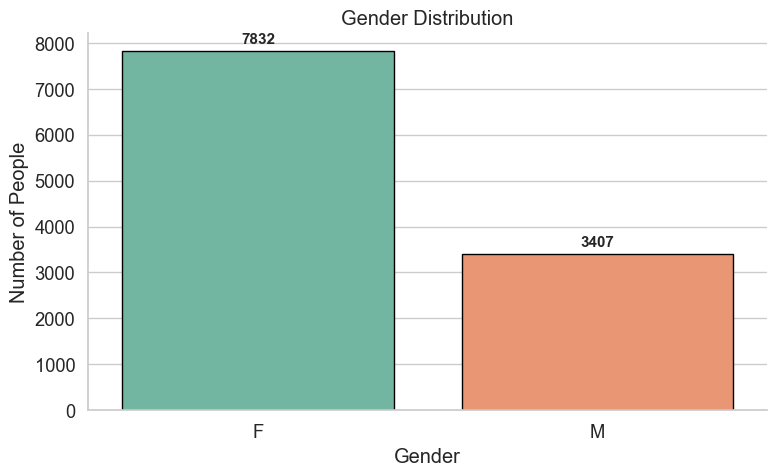

In [17]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 5))

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of People")

ax = sns.countplot(x="Gender",data=df,palette="Set2",edgecolor="black")
for bars in ax.containers:
    ax.bar_label(bars,
        label_type="edge",
        fontsize=11,
        fontweight="bold",
        padding=3)

sns.despine()

plt.tight_layout()
plt.show()

In [18]:
df.groupby('Gender')['Amount'].sum().reset_index()

,Gender,Amount
0,F,74335853
1,M,31913276


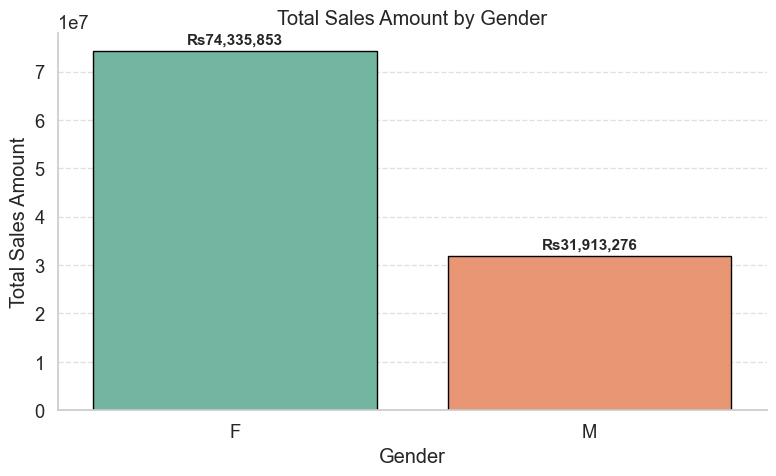

In [19]:
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 5))

plt.title("Total Sales Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")

sales_gen = df.groupby('Gender')['Amount'].sum().reset_index()

ax = sns.barplot(x='Gender',y='Amount',data=sales_gen,palette="Set2",edgecolor="black")
for bars in ax.containers:
    ax.bar_label(bars,
        fmt="Rs{:,.0f}",
        label_type="edge",
        fontsize=11,
        fontweight="bold",
        padding=3)

ax.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

#### From the above graphs, we can observe that the majority of buyers are female. Additionally, female customers demonstrate higher purchasing power compared to male customers.

# Age

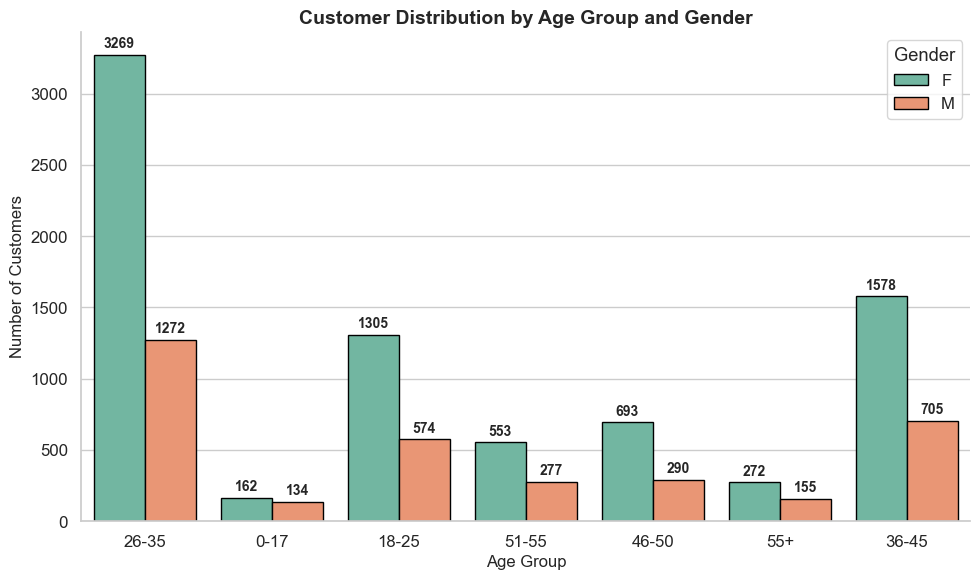

In [20]:
# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 6))

# Count plot
ax = sns.countplot(
    data=df,
    x="Age Group",
    hue="Gender",
    palette="Set2",
    edgecolor="black"
)

# Title & labels
plt.title("Customer Distribution by Age Group and Gender", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Bar labels
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=10,
        padding=3,
        fontweight="bold"
    )

# Legend customization
plt.legend(title="Gender")

# Remove top & right border
sns.despine()

# Adjust layout
plt.tight_layout()
plt.show()


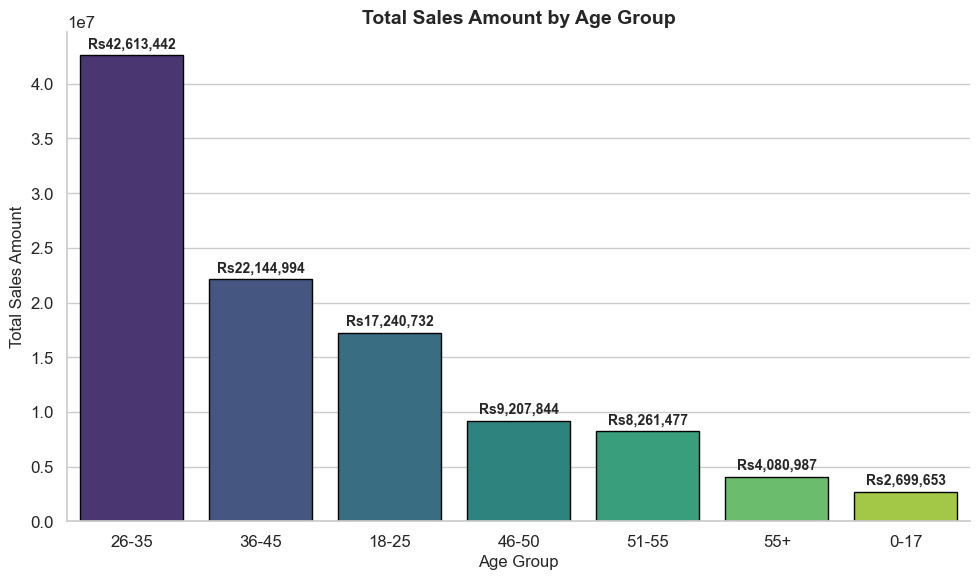

In [21]:
# Prepare aggregated data
sales_age = (
    df.groupby('Age Group',as_index=False)['Amount']
    .sum()
    .sort_values(by="Amount",ascending=False)
)

# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 6))

# Bar plot
ax = sns.barplot(
    x="Age Group",
    y="Amount",
    data=sales_age,
    palette="viridis",
    edgecolor="black"
)

# Title & axis labels
plt.title("Total Sales Amount by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Total Sales Amount", fontsize=12)

# Bar value labels
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="Rs{:,.0f}",
        fontsize=10,
        padding=3,
        fontweight="bold"
    )

# Remove extra borders
sns.despine()

# Adjust layout
plt.tight_layout()
plt.show()


#### The analysis indicates that female customers aged 26–35 years form the largest buyer segment.”

# State

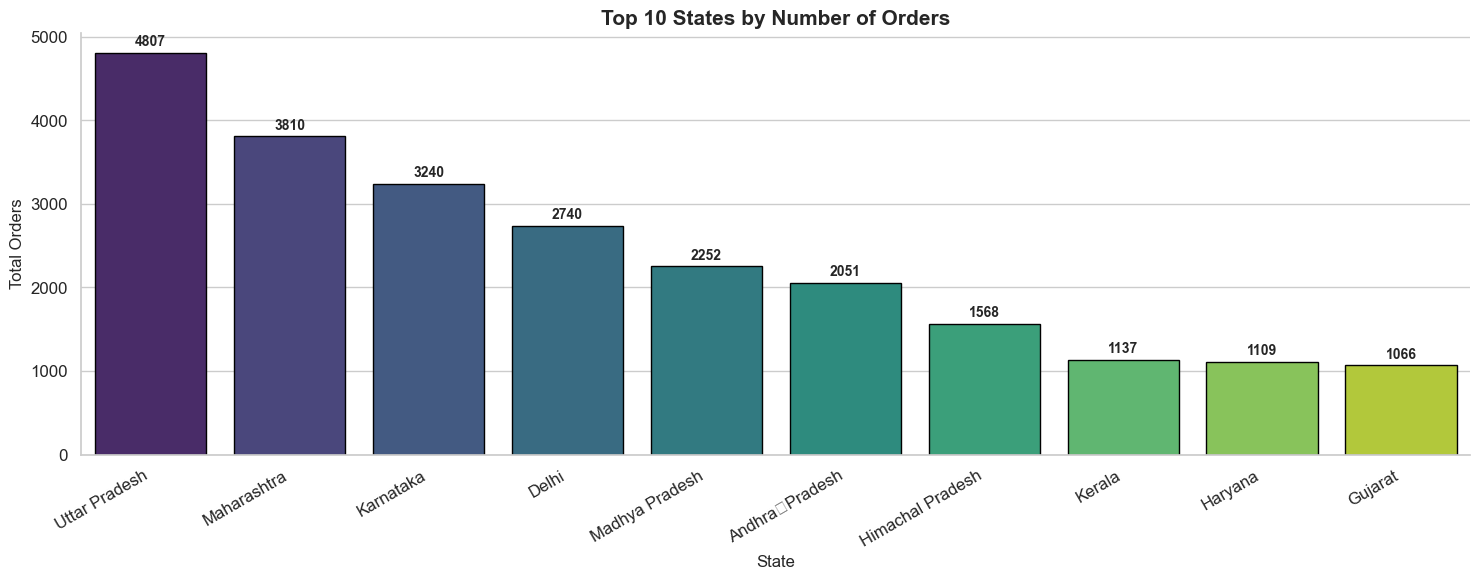

In [22]:
# Aggregate data (Top 10 states by orders)
sales_state = (
    df.groupby("State", as_index=False)["Orders"]
      .sum()
      .sort_values(by="Orders", ascending=False)
      .head(10)
)

# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(15, 6))

# Bar plot
ax = sns.barplot(
    data=sales_state,
    x="State",
    y="Orders",
    palette="viridis",
    edgecolor="black"
)

# Title & labels
plt.title("Top 10 States by Number of Orders", fontsize=15, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=30, ha="right")

# Bar value labels
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=10,
        padding=3,
        fontweight="bold"
    )

# Clean look
sns.despine()
plt.tight_layout()
plt.show()


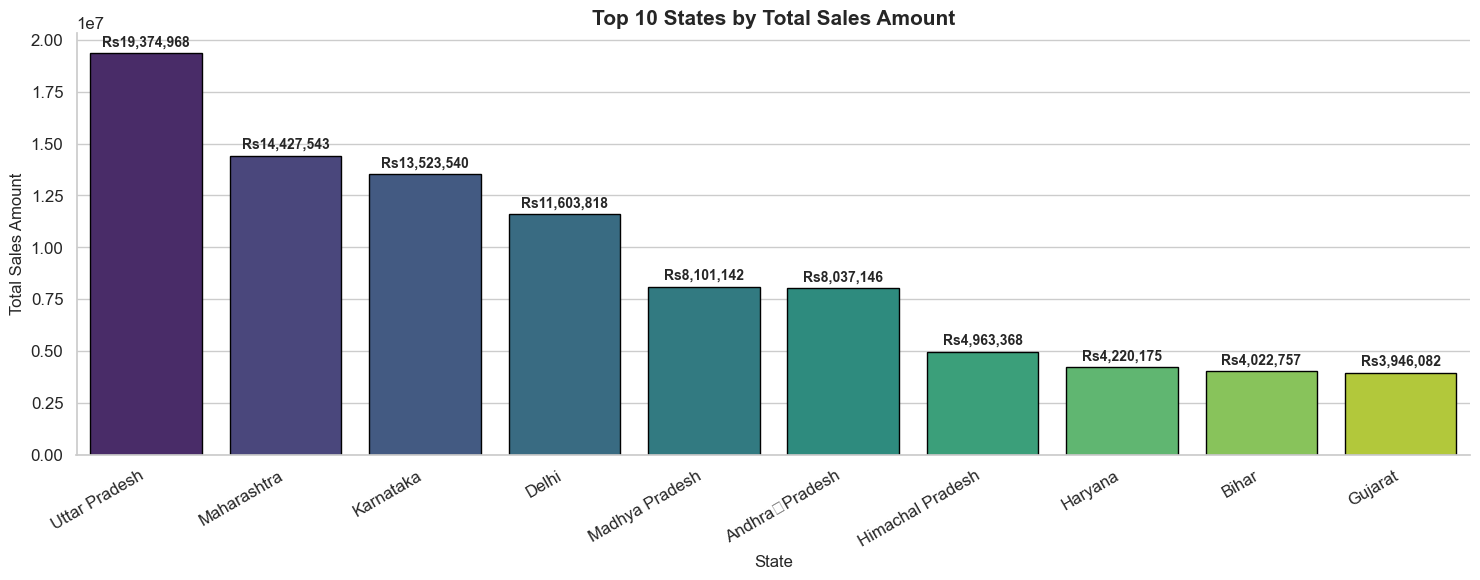

In [23]:
# Aggregate data: Top 10 states by sales amount
sales_state = (
    df.groupby("State", as_index=False)["Amount"]
      .sum()
      .sort_values(by="Amount", ascending=False)
      .head(10)
)

# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(15, 6))

# Bar plot
ax = sns.barplot(
    data=sales_state,
    x="State",
    y="Amount",
    palette="viridis",
    edgecolor="black"
)

# Title & axis labels
plt.title("Top 10 States by Total Sales Amount", fontsize=15, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Sales Amount", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha="right")

# Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="Rs{:,.0f}",
        fontsize=10,
        padding=3,
        fontweight="bold"
    )

# Clean dashboard look
sns.despine()
plt.tight_layout()
plt.show()


#### The analysis highlights that Uttar Pradesh, Maharashtra, and Karnataka are the top-performing states in terms of both order volume and total sales value.

# Marital Status

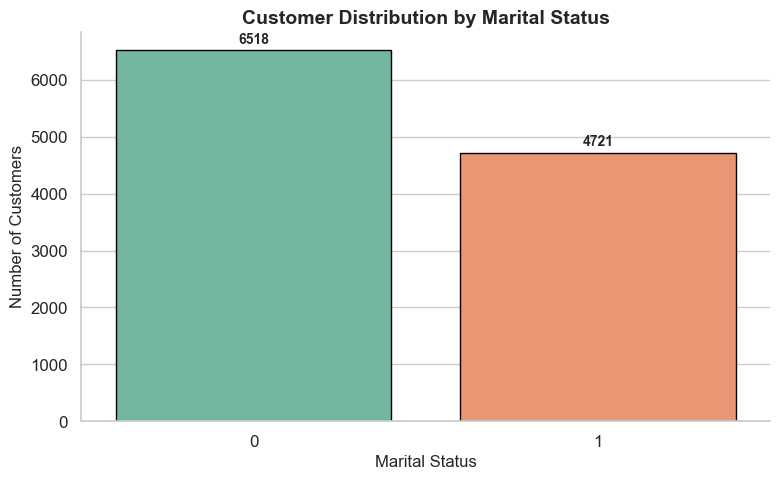

In [24]:
# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8, 5))

# Count plot
ax = sns.countplot(
    data=df,
    x="Marital_Status",
    palette="Set2",
    edgecolor="black"
)

# Title & labels
plt.title("Customer Distribution by Marital Status", fontsize=14, fontweight="bold")
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Bar labels
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=10,
        padding=3,
        fontweight="bold"
    )

# Clean look
sns.despine()
plt.tight_layout()
plt.show()


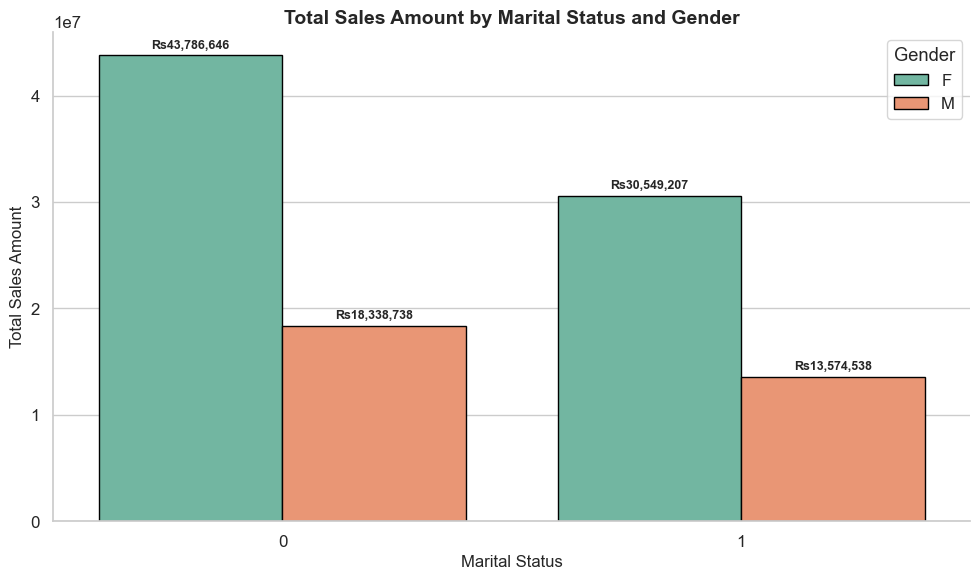

In [25]:
# Aggregate data: Sales by Marital Status and Gender
sales_state = (
    df.groupby(["Marital_Status", "Gender"], as_index=False)["Amount"]
      .sum()
      .sort_values(by="Amount", ascending=False)
)

# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 6))

# Bar plot
ax = sns.barplot(
    data=sales_state,
    x="Marital_Status",
    y="Amount",
    hue="Gender",
    palette="Set2",
    edgecolor="black"
)

# Title & axis labels
plt.title(
    "Total Sales Amount by Marital Status and Gender",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Total Sales Amount", fontsize=12)

# Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="Rs{:,.0f}",
        fontsize=9,
        padding=3,
        fontweight="bold"
    )

# Legend formatting
plt.legend(title="Gender")

# Clean dashboard look
sns.despine()
plt.tight_layout()
plt.show()


#### The analysis indicates that married women are the dominant buyer segment and contribute the highest purchasing power.

# Occupation

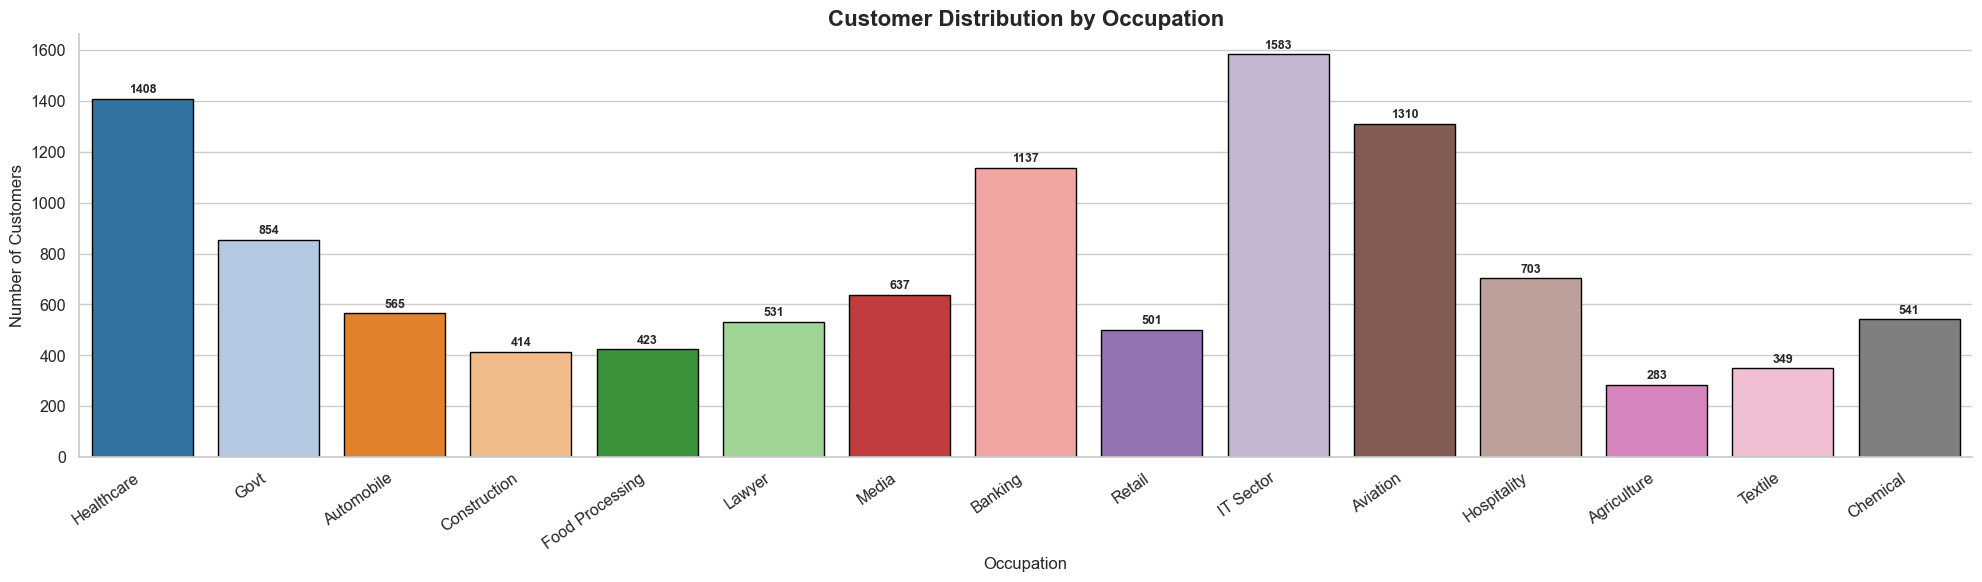

In [26]:
# Theme & figure size
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.figure(figsize=(20, 6))

# Count plot
ax = sns.countplot(
    data=df,
    x="Occupation",
    palette="tab20",
    edgecolor="black"
)

# Title & axis labels
plt.title(
    "Customer Distribution by Occupation",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Occupation", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=35, ha="right")

# Add bar labels
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=9,
        padding=2,
        fontweight="bold"
    )

# Clean dashboard look
sns.despine()
plt.tight_layout()
plt.show()


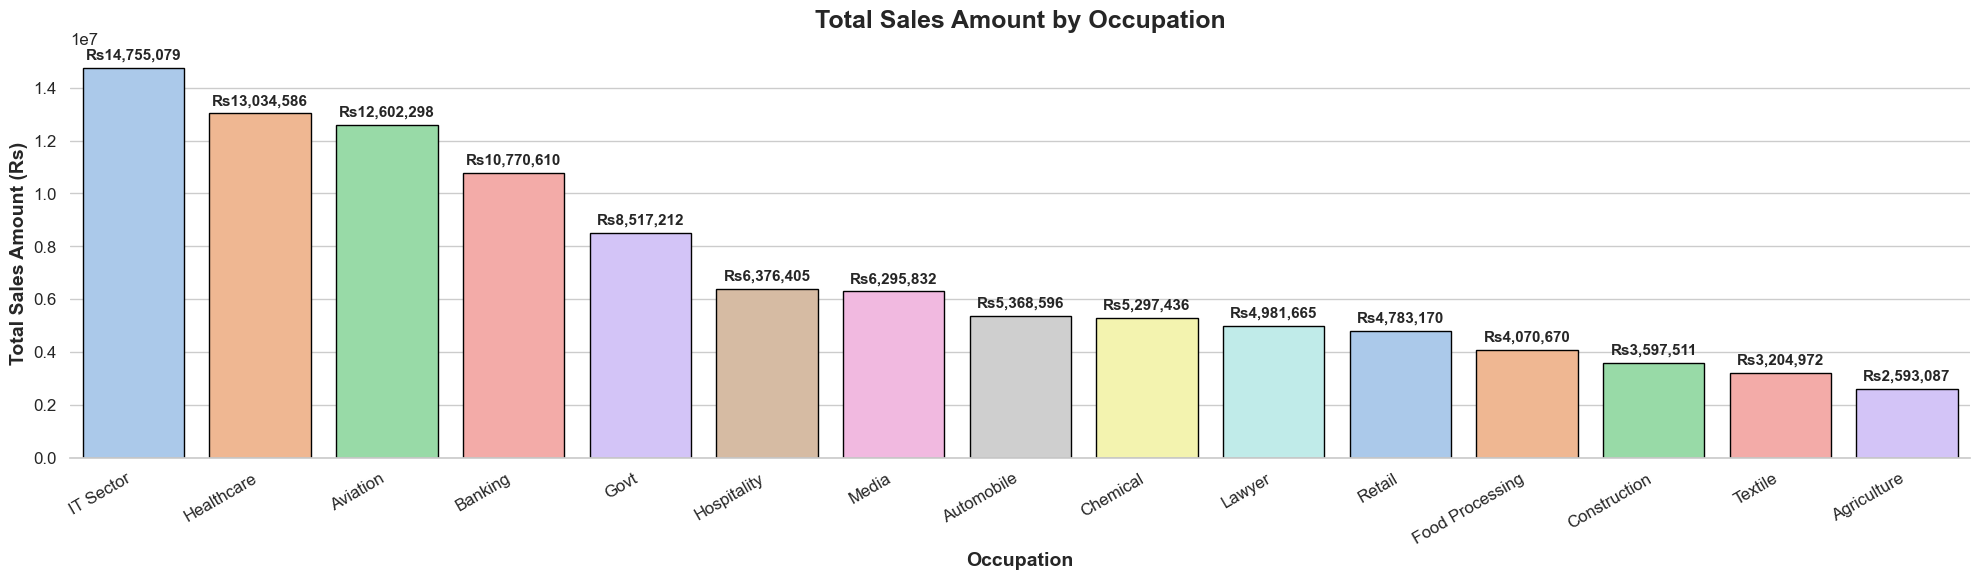

In [36]:
# 1. Aggregate sales by Occupation
Sales_state = (
    df.groupby("Occupation", as_index=False)["Amount"]
      .sum()
      .sort_values(by="Amount", ascending=False)
)

# 2. Set theme for professional look
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "axes.titleweight": "bold",
        "axes.labelweight": "bold"
    }
)

# 3. Create figure
plt.figure(figsize=(20, 6))

# 4. Bar plot
ax = sns.barplot(
    data=Sales_state,
    x="Occupation",
    y="Amount",
    palette="pastel",
    edgecolor="black"
)

# 5. Titles & labels
ax.set_title("Total Sales Amount by Occupation", fontsize=18, pad=15)
ax.set_xlabel("Occupation", fontsize=14)
ax.set_ylabel("Total Sales Amount (Rs)", fontsize=14)

# 6. Rotate x labels for better readability
plt.xticks(rotation=30, ha="right")

# 7. Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="Rs{:,.0f}",
        fontsize=11,
        fontweight="bold",
        padding=4
    )

# 8. Remove top & right borders (clean look)
sns.despine(left=True, bottom=False)

# 9. Adjust layout
plt.tight_layout()

# 10. Show plot
plt.show()


#### *The analysis shows that buyers from the IT, Healthcare, and Aviation sectors contribute the highest participation*

# Product_Category

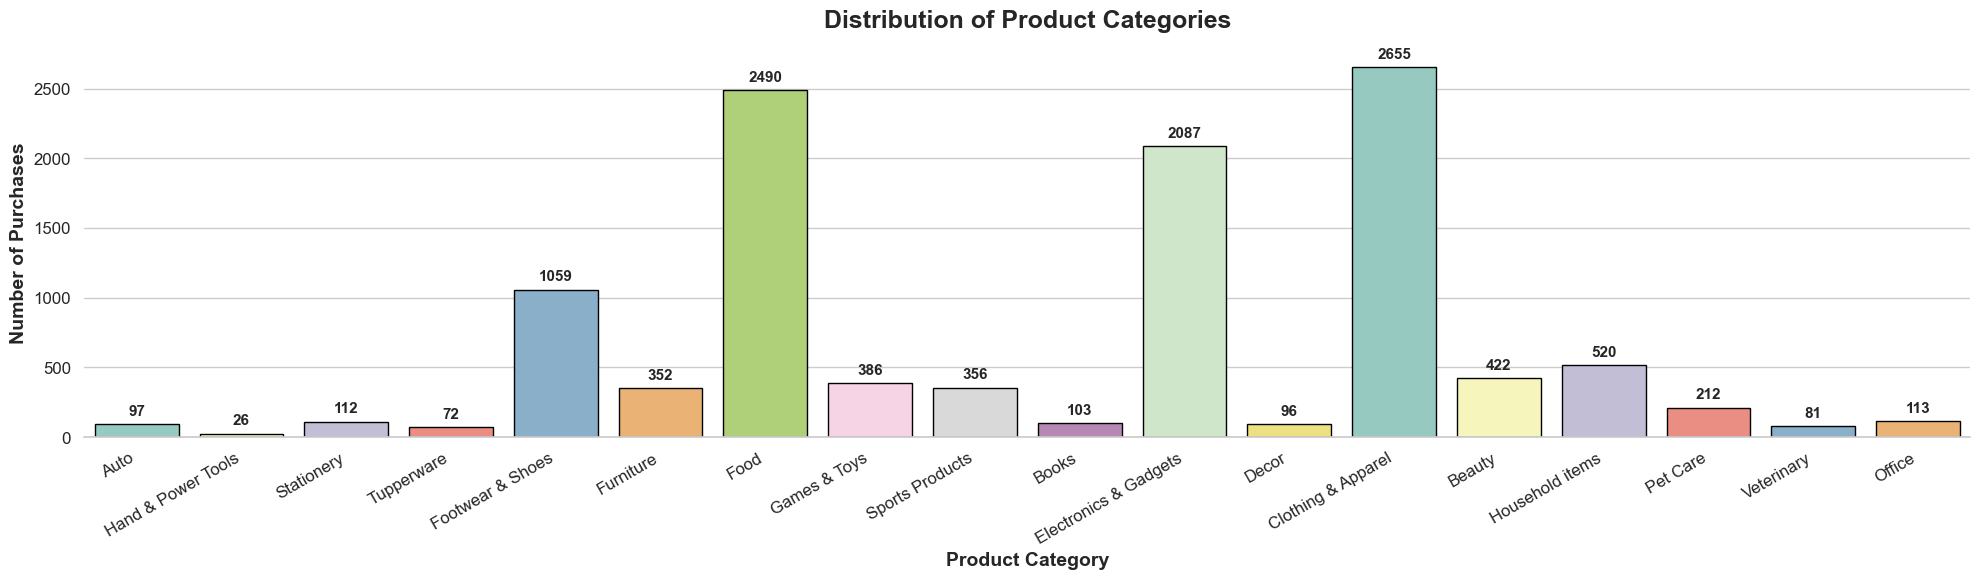

In [48]:
# 1. Set professional theme
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "axes.titleweight": "bold",
        "axes.labelweight": "bold"
    }
)

# 2. Create figure
plt.figure(figsize=(20, 6))

# 3. Count plot
ax = sns.countplot(
    data=df,
    x="Product_Category",
    palette="Set3",
    edgecolor="black"
)

# 4. Titles & labels
ax.set_title("Distribution of Product Categories", fontsize=18, pad=15)
ax.set_xlabel("Product Category", fontsize=14)
ax.set_ylabel("Number of Purchases", fontsize=14)

# 5. Rotate x-axis labels for readability
plt.xticks(rotation=30, ha="right")

# 6. Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=11,
        fontweight="bold",
        padding=4
    )

# 7. Clean chart borders
sns.despine(left=True, bottom=False)

# 8. Adjust layout
plt.tight_layout()

# 9. Show plot
plt.show()


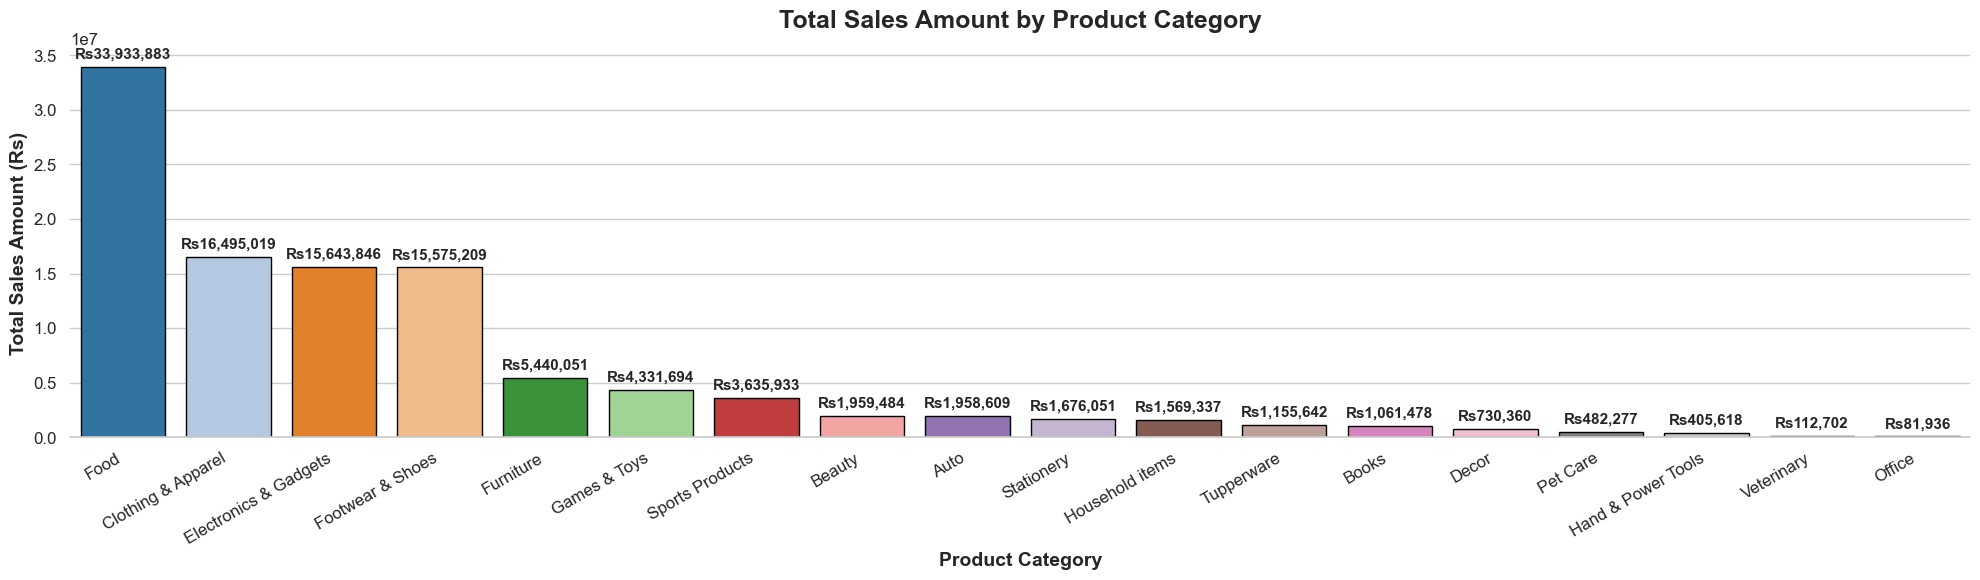

In [69]:
# 1. Aggregate total sales by Product Category
Sales_Products = (
    df.groupby("Product_Category", as_index=False)["Amount"]
      .sum()
      .sort_values(by="Amount", ascending=False)
)

# 2. Set a professional theme
sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

# 3. Create figure
plt.figure(figsize=(20, 6))

# 4. Bar plot
ax = sns.barplot(
    data=Sales_Products,
    x="Product_Category",
    y="Amount",
    palette="tab20",
    edgecolor="black"
)

# 5. Add title and labels
ax.set_title("Total Sales Amount by Product Category", fontsize=18, pad=15)
ax.set_xlabel("Product Category", fontsize=14)
ax.set_ylabel("Total Sales Amount (Rs)", fontsize=14)

# 6. Rotate x-axis labels for clarity
plt.xticks(rotation=30, ha="right")

# 7. Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt="Rs{:,.0f}",
        fontsize=11,
        fontweight="bold",
        padding=4
    )

# 8. Clean chart borders
sns.despine(left=True, bottom=False)

# 9. Adjust layout
plt.tight_layout()

# 10. Display plot
plt.show()


#### The data indicates that most buyers belong to the Food, Clothing & Apparel, and Electronics & Gadgets categories.

In [70]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra�Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


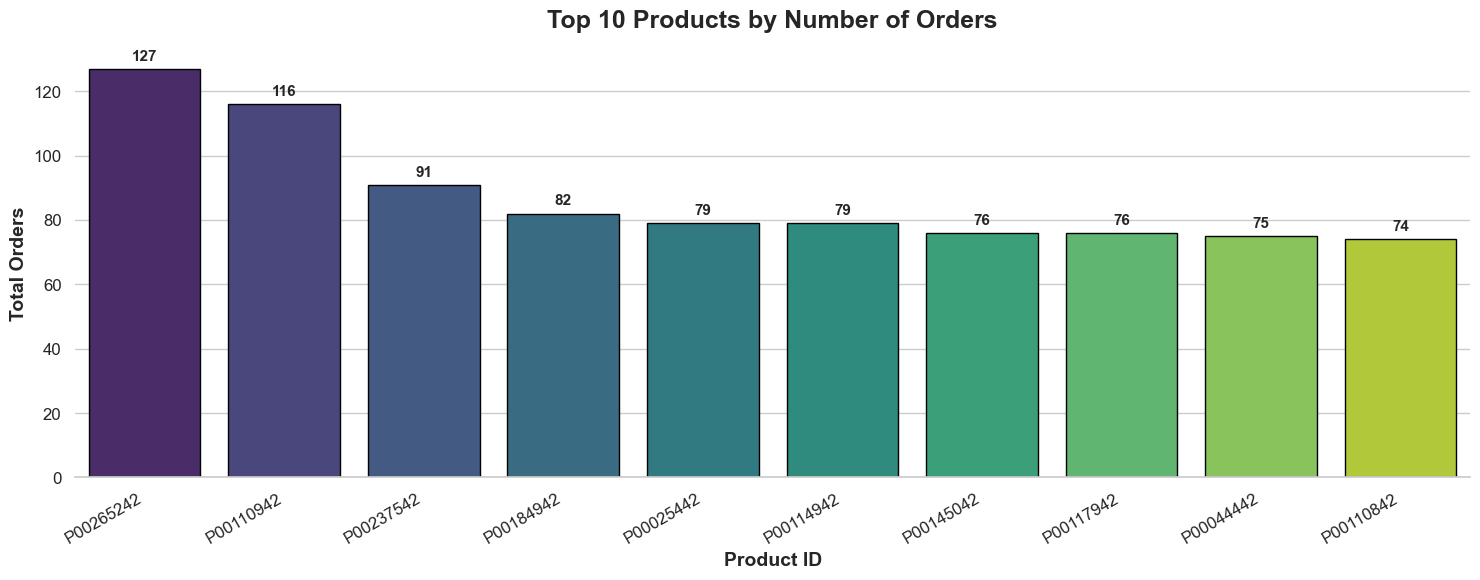

In [82]:
# 1. Aggregate total orders by Product ID (Top 10)
Sales_data = (
    df.groupby("Product_ID", as_index=False)["Orders"]
      .sum()
      .sort_values(by="Orders", ascending=False)
      .head(10)
)

# 2. Set professional theme
sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

# 3. Create figure
plt.figure(figsize=(15,6))

# 4. Bar plot
ax = sns.barplot(
    data=Sales_data,
    x="Product_ID",
    y="Orders",
    palette="viridis",
    edgecolor="black"
)

# 5. Titles & labels
ax.set_title("Top 10 Products by Number of Orders", fontsize=18, pad=15)
ax.set_xlabel("Product ID", fontsize=14)
ax.set_ylabel("Total Orders", fontsize=14)

# 6. Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha="right")

# 7. Add value labels on bars
for bars in ax.containers:
    ax.bar_label(
        bars,
        fontsize=11,
        fontweight="bold",
        padding=4
    )

# 8. Clean chart borders
sns.despine(left=True, bottom=False)

# 9. Adjust layout
plt.tight_layout()

# 10. Show plot
plt.show()


# Conclusion

#### The analysis indicates that married women aged 26–35 from UP, Maharashtra, and Karnataka in IT, Healthcare, and Aviation show higher purchasing preference for Food, Clothing, and Electronics categories.